# Premium Prediction for Health insurance

# Step-1 : EDA

In [66]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
# loading dataset
df = pd.read_excel("premiums.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


# EDA + Data Cleaning

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [69]:
df.Income_Level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object)

In [70]:
df.shape

(50000, 13)

In [71]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [72]:
df.columns = df.columns.str.replace(" " , "_")

In [73]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number_Of_Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical_History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [74]:
df.columns = df.columns.str.lower()

In [75]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Handle the Null values

In [76]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [77]:
df.dropna(inplace = True)

In [78]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [79]:
df.shape

(49976, 13)

## Handle duplicate values

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


# Numerical columns : Univariate analysis

In [82]:
## Issue-1 : number_of_dependants cannot be in negative

df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
402,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309
2245,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095
2323,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641
2986,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995
3756,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48062,23,Male,Northwest,Unmarried,-1,Normal,No Smoking,Freelancer,> 40L,54,No Disease,Gold,13601
48086,36,Female,Southwest,Married,-1,Obesity,Occasional,Salaried,<10L,3,Diabetes,Bronze,14422
49256,60,Female,Southwest,Married,-1,Normal,No Smoking,Self-Employed,10L - 25L,21,Thyroid,Bronze,10141
49270,34,Male,Southeast,Married,-1,Obesity,No Smoking,Self-Employed,10L - 25L,17,Diabetes & Thyroid,Silver,21816


In [83]:
df.number_of_dependants.unique()

array([ 0,  2,  3,  4,  1,  5, -3, -1])

In [84]:
df['number_of_dependants'] = df.number_of_dependants.abs()

In [85]:
df.number_of_dependants.unique()

array([0, 2, 3, 4, 1, 5])

In [86]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.717284,23.021150,15766.810189
std,15.000378,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


## Handle the Outliers

In [87]:
numeric_columns = df.select_dtypes(include = ['int64', 'float64']).columns
numeric_columns                             

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

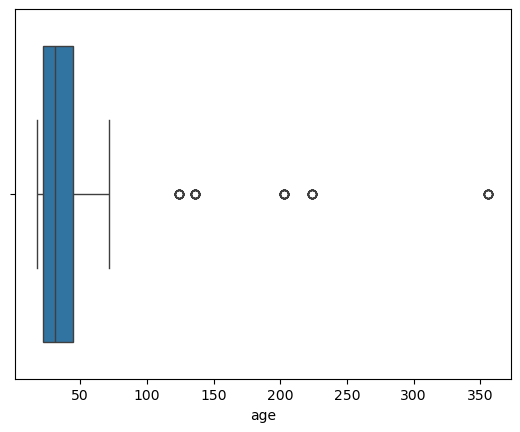

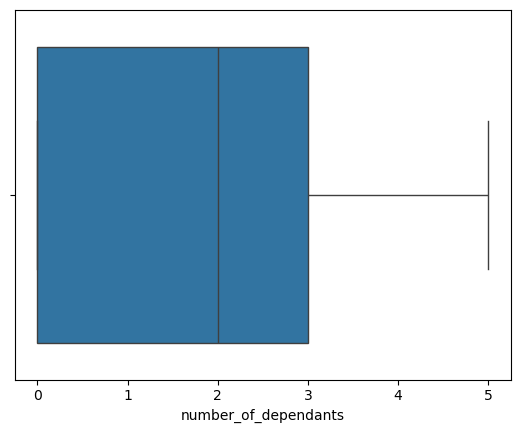

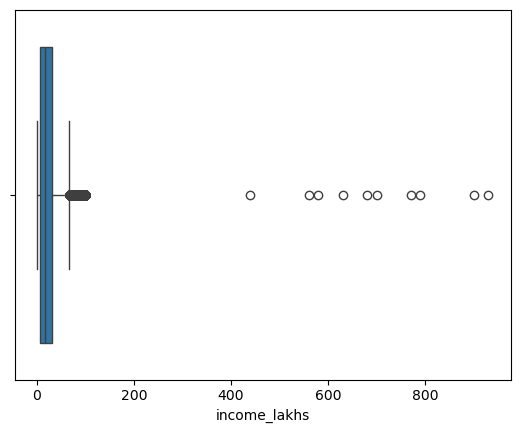

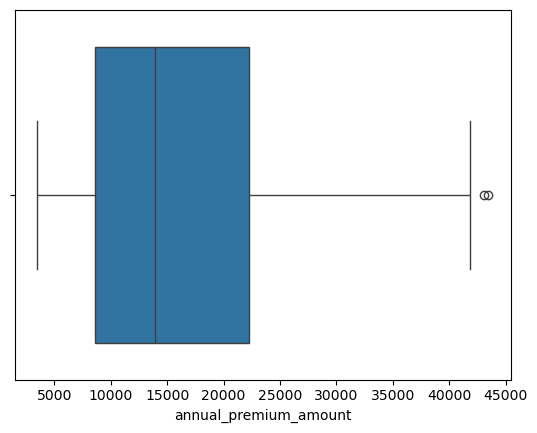

In [88]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

## Handling the Age Outlier

In [89]:
df[df.age > 100]['age'].count()

np.int64(58)

In [90]:
df[df.age > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [91]:
median = df.age.median()
median

31.0

In [92]:
df.loc[df.age > 100, 'age'] = median

In [93]:
df[df.age > 100]['age'].count()

np.int64(0)

In [94]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.397891,1.717284,23.021150,15766.810189
std,13.674149,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,72.000000,5.000000,930.000000,43471.000000


In [95]:
## Outliers in income_lakhs > 1CR (100)

df[df.income_lakhs > 100]['income_lakhs'].count()

np.int64(10)

In [96]:
# Number of outliers using IQR

Q1, Q3 = df.income_lakhs.quantile([0.25, 0.75])
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

LB, UB

(-29.0, 67.0)

In [97]:
df[df.income_lakhs > UB]['income_lakhs'].count()

np.int64(3560)

In [98]:
df = df[df.income_lakhs <= 100]

In [99]:
df.shape

(49966, 13)

In [100]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49966.000000,49966.000000,49966.000000,49966.000000
mean,34.397630,1.717308,22.886063,15765.961574
std,13.674151,1.491911,22.166488,8419.532784
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.250000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,100.000000,43471.000000


# EDA & DC on Caegorical data

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49966 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    49966 non-null  int64 
 1   gender                 49966 non-null  object
 2   region                 49966 non-null  object
 3   marital_status         49966 non-null  object
 4   number_of_dependants   49966 non-null  int64 
 5   bmi_category           49966 non-null  object
 6   smoking_status         49966 non-null  object
 7   employment_status      49966 non-null  object
 8   income_level           49966 non-null  object
 9   income_lakhs           49966 non-null  int64 
 10  medical_history        49966 non-null  object
 11  insurance_plan         49966 non-null  object
 12  annual_premium_amount  49966 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.3+ MB


In [102]:
categorical_columns = df.select_dtypes(include = ['object']).columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [103]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [104]:
df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_1604\2744095914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})


In [105]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [106]:
df.shape

(49966, 13)

# Step-2 : Feature Engineering

In [107]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [108]:
risk_score = {
    'Diabetes' : 6,
    'Heart disease' : 8,
    'High blood pressure' : 6,
    'Thyroid' : 5,
    'No Disease' : 0
}

In [109]:
df1 = df.copy()

In [110]:
df1[['disease1', 'disease2']] = df1['medical_history'].str.split(" & ", expand = True)

In [111]:
df1.disease1 = df1.disease1.map(risk_score)

In [112]:
df1.disease2 = df1.disease2.map(risk_score)

In [113]:
df1.disease1.isnull().sum()

np.int64(0)

In [114]:
df1.disease2.isnull().sum()

np.int64(45192)

In [115]:
df1.disease2 = df1.disease2.fillna(0)

In [116]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,6,0.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,6,0.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,6,0.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,0,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,5,0.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,0,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490,0,0.0


In [117]:
df1['total_risk_score'] = df1['disease1'] + df1['disease2']

In [119]:
df1 = df1.drop(['medical_history', 'disease1', 'disease2'], axis = 1)
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,5.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,Bronze,9490,0.0


In [121]:
# checking sub-categories of each column
categorical_columns = df1.select_dtypes(include = ['object']).columns
categorical_columns

for col in categorical_columns:
    print(col, " : ", df1[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


### Apply Ordinal encoding to convert insurance_plan & income_level into neumerical

In [122]:
# use ordinal encoding when Order/Ranking matters

In [123]:
from sklearn.preprocessing import OrdinalEncoder

In [124]:
encoder = OrdinalEncoder(categories = [['Bronze','Silver','Gold']])
df1['insurance_plan'] = encoder.fit_transform(df1[['insurance_plan']])

In [125]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,0.0,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,0.0,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,1.0,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,2.0,20303,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,1.0,13365,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,0.0,9111,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,2.0,27076,5.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,0.0,8564,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,0.0,9490,0.0


In [ ]:
## Apply Label encoder on region and bmi_category